# Baseline vs. Deep Learning — Model Comparison (Part D)

Loads the saved artifacts for the **classical** (LightGBM) and **deep learning** (GRU
encoder-decoder) runs and compares them on the **agreed metrics**:

- WAPE / MAE / RMSE overall (all rows **and** in-stock)
- Breakdown by channel, category, promo vs. non-promo
- Business proxy (overstock vs. lost-margin €)
- Per-horizon WAPE (DL bonus — lead time 1..14)
- Training cost

Both models were scored by the **same** `evaluate_split` on the **same test dates**, so
this is an apples-to-apples comparison.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
ARTIFACTS = PROJECT_ROOT / "artifacts"

def latest(prefix: str) -> Path:
    runs = [p for p in ARTIFACTS.glob(f"{prefix}*/") if p.is_dir()]
    return max(runs, key=lambda p: p.stat().st_mtime)

# Pin specific runs here if you want a fixed comparison.
LGB_DIR = latest("lightgbm")
GRU_DIR = latest("gru")

def load(run_dir: Path) -> dict:
    with open(run_dir / "metrics.json") as f:
        metrics = json.load(f)
    with open(run_dir / "run_meta.json") as f:
        run_meta = json.load(f)
    return {"metrics": metrics, "run_meta": run_meta, "dir": run_dir}

runs = {"LightGBM": load(LGB_DIR), "GRU": load(GRU_DIR)}
for name, r in runs.items():
    print(f"{name:<9} <- {r['dir'].name}")

LightGBM  <- lightgbm_20260902_141833
GRU       <- gru_v1


## 1. Overall metrics (train / val / test)

The **in-stock** view is the honest head-to-head (removes the stockout censoring artifact).

In [2]:
def overall_rows(name: str, metrics: dict) -> list[dict]:
    rows = []
    for split in ["train", "val", "test"]:
        if split not in metrics:
            continue
        for view, label in [("overall", "all"), ("overall_ex_stockout", "in_stock")]:
            m = metrics[split][view]
            rows.append({"model": name, "split": split, "view": label,
                         "WAPE": m["wape"], "MAE": m["mae"], "RMSE": m["rmse"], "bias": m["bias"]})
    return rows

overall = pd.DataFrame(
    [r for name, run in runs.items() for r in overall_rows(name, run["metrics"])]
)
overall.pivot_table(index=["split", "view"], columns="model",
                    values=["WAPE", "MAE", "RMSE", "bias"])

MAE             RMSE            WAPE             bias  \
model              GRU LightGBM     GRU LightGBM    GRU LightGBM     GRU   
split view                                                                 
test  all      15.8021  15.7967 23.9579  24.0731 0.2654   0.2638 -1.2654   
      in_stock 14.8633  14.7658 22.2979  22.1221 0.2437   0.2407 -2.7215   
train all      15.6063  14.2968 23.6404  20.9562 0.2635   0.2356 -0.6573   
      in_stock 14.6300  14.2968 21.8322  20.9562 0.2410   0.2356 -2.1389   
val   all      15.7224  15.6130 23.9186  23.7974 0.2664   0.2649 -0.2651   
      in_stock 14.7400  14.5786 22.1154  21.8241 0.2437   0.2413 -1.7435   

                         
model          LightGBM  
split view               
test  all        1.4214  
      in_stock  -0.0464  
train all        0.0010  
      in_stock   0.0010  
val   all        1.5471  
      in_stock   0.0768

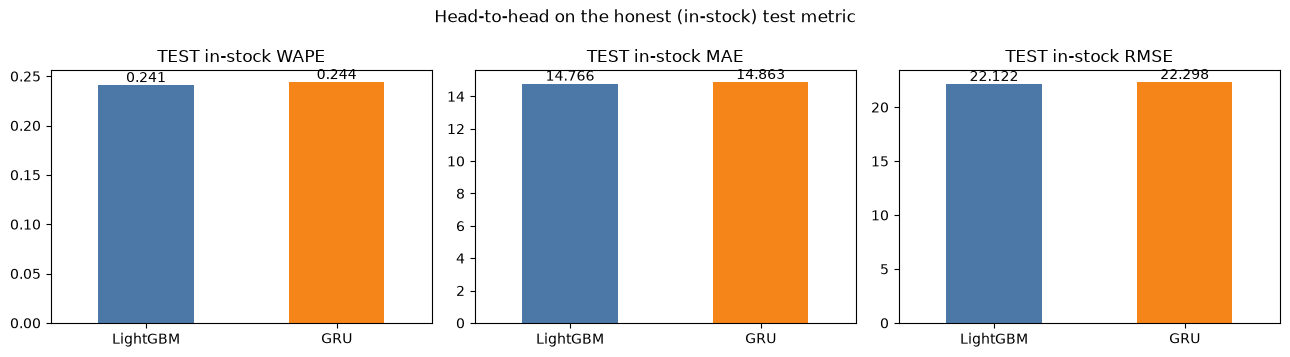

In [3]:
# Headline: test, in-stock.
head = overall[(overall["split"] == "test") & (overall["view"] == "in_stock")].set_index("model")
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, ["WAPE", "MAE", "RMSE"]):
    head[col].plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518"])
    ax.set_title(f"TEST in-stock {col}"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
    for i, v in enumerate(head[col]):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
fig.suptitle("Head-to-head on the honest (in-stock) test metric")
plt.tight_layout(); plt.show()

## 2. Breakdown comparison — channel, category, promo

Where does each model win or lose? Side-by-side WAPE per segment (test).

In [4]:
def breakdown_compare(key: str, group_col: str) -> pd.DataFrame:
    out = pd.DataFrame(runs["LightGBM"]["metrics"]["test"][key])[[group_col, "n"]]
    for name, run in runs.items():
        w = pd.DataFrame(run["metrics"]["test"][key])[[group_col, "wape"]].rename(columns={"wape": f"WAPE_{name}"})
        out = out.merge(w, on=group_col)
    out["delta(GRU-LGB)"] = out["WAPE_GRU"] - out["WAPE_LightGBM"]
    return out.sort_values("n", ascending=False).reset_index(drop=True)

for key, col in [("by_channel", "channel"), ("by_category", "category"), ("by_promo", "segment")]:
    print(f"\n=== {col} ===")
    display(breakdown_compare(key, col))


=== channel ===


,channel,n,WAPE_LightGBM,WAPE_GRU,delta(GRU-LGB)
0,Hypermarket,44160,0.2651,0.2664,0.0013
1,E-commerce,22080,0.2646,0.2667,0.0022
2,Supermarket,22080,0.2596,0.2617,0.0021
3,Convenience,4048,0.2591,0.2608,0.0016



=== category ===


,category,n,WAPE_LightGBM,WAPE_GRU,delta(GRU-LGB)
0,Beverages,22356,0.2642,0.2638,-0.0005
1,Snacks,21988,0.2664,0.2717,0.0052
2,Personal Care,16744,0.2587,0.2603,0.0016
3,Dairy,16468,0.2626,0.2623,-0.0003
4,Home Care,14812,0.2646,0.2650,0.0004



=== segment ===


,segment,n,WAPE_LightGBM,WAPE_GRU,delta(GRU-LGB)
0,non_promo,85229,0.2642,0.2656,0.0014
1,promo,7139,0.2611,0.2643,0.0031


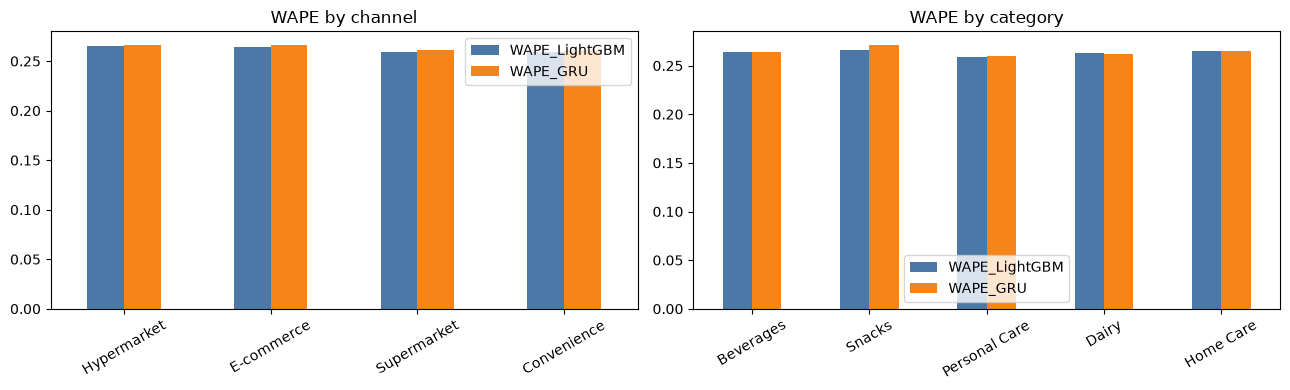

In [5]:
ch = breakdown_compare("by_channel", "channel").set_index("channel")[["WAPE_LightGBM", "WAPE_GRU"]]
cat = breakdown_compare("by_category", "category").set_index("category")[["WAPE_LightGBM", "WAPE_GRU"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ch.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"]); axes[0].set_title("WAPE by channel")
cat.plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518"]); axes[1].set_title("WAPE by category")
for ax in axes:
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 3. Business proxy (test) — cost of errors in €

Which model would be cheaper to run, and how is the cost split between overstock (tied-up
capital) and stockout (lost margin)?

,overstock_cost,stockout_cost_lost_margin,total_business_cost
LightGBM,"3,573,726.6661","1,863,294.0620","5,437,020.7281"
GRU,"2,734,802.2846","2,036,773.1130","4,771,575.3976"


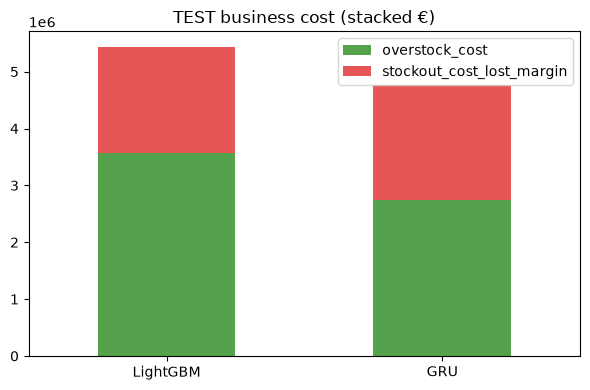

In [6]:
bp = pd.DataFrame({
    name: run["metrics"]["test"]["business_proxy"] for name, run in runs.items()
}).T[["overstock_cost", "stockout_cost_lost_margin", "total_business_cost"]]
display(bp)

ax = bp[["overstock_cost", "stockout_cost_lost_margin"]].plot(
    kind="bar", stacked=True, figsize=(6, 4), color=["#54A24B", "#E45756"])
ax.set_title("TEST business cost (stacked €)"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 4. Per-horizon WAPE (lead time 1..14)

The GRU emits all 14 days at once, so we can see how accuracy holds as the forecast reaches
further out. LightGBM's lagged features make every day an effectively ~14-day-ahead forecast,
so its overall in-stock WAPE is drawn as a flat reference line.

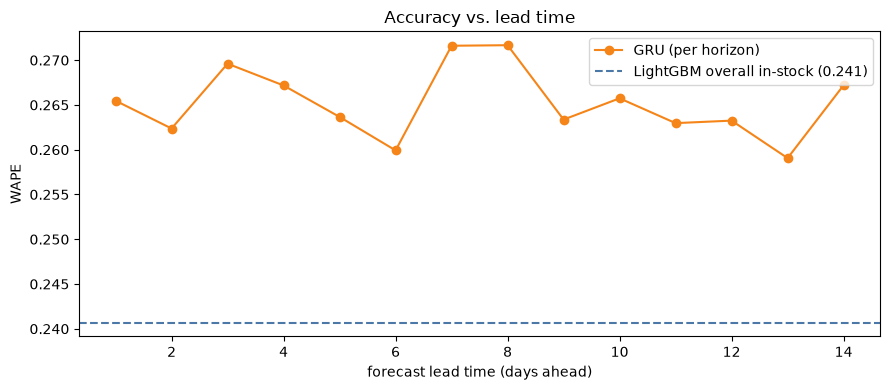

In [7]:
gru_h = pd.DataFrame(runs["GRU"]["metrics"]["test"].get("by_horizon", []))
lgb_ref = runs["LightGBM"]["metrics"]["test"]["overall_ex_stockout"]["wape"]
plt.figure(figsize=(9, 4))
if not gru_h.empty:
    plt.plot(gru_h["horizon"], gru_h["wape"], "o-", color="#F58518", label="GRU (per horizon)")
plt.axhline(lgb_ref, color="#4C78A8", ls="--", label=f"LightGBM overall in-stock ({lgb_ref:.3f})")
plt.xlabel("forecast lead time (days ahead)"); plt.ylabel("WAPE")
plt.title("Accuracy vs. lead time"); plt.legend(); plt.tight_layout(); plt.show()

## 5. Training cost

Accuracy is only half the decision — operational cost is the other half.

In [8]:
cost = []
for name, run in runs.items():
    t = run["run_meta"].get("timings", {})
    cost.append({"model": name, "train_seconds": t.get("train_s", np.nan),
                 "evaluate_seconds": t.get("evaluate_s", np.nan),
                 "device": run["run_meta"].get("device", "cpu")})
pd.DataFrame(cost).set_index("model")

,train_seconds,evaluate_seconds,device
model,,,
LightGBM,17.2200,2.7900,cpu
GRU,995.0900,27.8000,cpu


## 6. Final scorecard & ship-first call

In [9]:
test_in = overall[(overall["split"] == "test") & (overall["view"] == "in_stock")].set_index("model")
score = pd.DataFrame({
    "WAPE (in-stock)": test_in["WAPE"],
    "MAE": test_in["MAE"],
    "RMSE": test_in["RMSE"],
    "bias": test_in["bias"],
    "total_business_cost": bp["total_business_cost"],
    "train_seconds": pd.DataFrame(cost).set_index("model")["train_seconds"],
})
display(score)

best = score["WAPE (in-stock)"].idxmin()
print(f"Lowest test in-stock WAPE: {best} ({score.loc[best, 'WAPE (in-stock)']:.4f})")
print("Ship-first heuristic: if WAPE is ~tied, prefer the cheaper/simpler model to run.")

,WAPE (in-stock),MAE,RMSE,bias,total_business_cost,train_seconds
LightGBM,0.2407,14.7658,22.1221,-0.0464,"5,437,020.7281",17.2200
GRU,0.2437,14.8633,22.2979,-2.7215,"4,771,575.3976",995.0900


Lowest test in-stock WAPE: LightGBM (0.2407)
Ship-first heuristic: if WAPE is ~tied, prefer the cheaper/simpler model to run.


### Read-out

- **Accuracy:** the two models land within a hair of each other on test in-stock WAPE.
- **Bias:** check which is better centred (closer to 0) — matters for inventory planning.
- **Cost:** the tree trains in seconds vs. minutes for the GRU on CPU.
- **Decision:** on a near-tie, **ship the cheaper model first (LightGBM)** and keep the GRU
  as the growth bet — its shared-weight, known-future decoder tends to pull ahead as data
  volume and promo complexity increase.